
# Lab 06 — AI-Assisted k-Nearest Neighbors Comparison
**Subject:** 23CSE301  
**Project dataset:** Sleep-EDF Database Expanded  
**Comparison baseline:** Lab 05 kNN notebook (student-written modular implementation)  

## Lab 06 requirement mapping
- **A1:** Repeat the Lab 05 experiments using a GenAI-assisted implementation and clearly identify the GenAI tool in code comments.
- **A2:** Run AI-generated unit tests on both the **Lab 05 student-written functions** and the **Lab 06 GenAI-assisted functions**.
- **A3:** Compare three kNN versions on the same project train/test split:
  1. Lab 05 student-written kNN
  2. `sklearn.neighbors.KNeighborsClassifier`
  3. GenAI-assisted kNN
- Report **Accuracy, Precision, Recall, F1-score**, and **mean computational time over 10 runs**.
- Export unit-test, functional-test, metric, runtime, prediction, and k-sweep results as CSV files.

> **GenAI tool used for Lab 06:** ChatGPT (OpenAI).  
> The Lab 05 baseline functions below are reproduced from the previously submitted Lab 05 notebook so the comparison is direct.



## 1. Setup

The notebook is designed for **Google Colab**. Upload the same Sleep-EDF PSG and Hypnogram EDF files used for Lab 05.  
No Google Drive path is required.


In [1]:

!pip install mne -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 49.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:

# Core imports
import os
import glob
import time
import unittest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42
K_DEFAULT = 3
N_BENCHMARK_RUNS = 10

np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.



## 2. Upload the Sleep-EDF project files

Upload the two EDF files used in Lab 05:
- the PSG file, containing `PSG` in its filename;
- the annotation/hypnogram file, containing `Hypnogram` in its filename.

If the files are already visible in `/content`, the upload step can be skipped.


In [3]:

# Colab upload helper
# Run this cell if the EDF files are not already present in /content.
try:
    from google.colab import files
    print("Upload the Sleep-EDF PSG and Hypnogram EDF files.")
    uploaded = files.upload()
    print("Uploaded:", list(uploaded.keys()))
except ImportError:
    print("Not running in Google Colab. Place the EDF files in the current working directory.")


Upload the Sleep-EDF PSG and Hypnogram EDF files.


Saving sleep-edf-sample.zip to sleep-edf-sample.zip
Uploaded: ['sleep-edf-sample.zip']



## 3. Lab 05 baseline — student-written modular functions

The following functions are the **Lab 05 baseline** and are kept conceptually unchanged for a fair comparison.  
They provide feature extraction, encoding, missing-value handling, distance calculation, sorting, neighbour selection, majority voting, and the student-written kNN classifier.


In [4]:

# ============================================================
# LAB 05 BASELINE
# Source: student's previous Lab 05 notebook.
# These functions are the student-written comparison baseline.
# ============================================================

def load_epoch_signals(psg_path, hypnogram_path, epoch_sec=30):
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    annotations = mne.read_annotations(hypnogram_path)
    raw.set_annotations(annotations, emit_warning=False)

    sfreq = raw.info['sfreq']
    ch_names = [ch for ch in raw.ch_names if ch not in ('Event marker', 'Temp rectal')]
    data = raw.get_data(picks=ch_names)

    samples_per_epoch = int(epoch_sec * sfreq)
    epoch_signals = []
    epoch_labels = []

    for onset, duration, description in zip(
        annotations.onset, annotations.duration, annotations.description
    ):
        n_sub_epochs = int(duration // epoch_sec)

        for i in range(n_sub_epochs):
            start_sample = int((onset + i * epoch_sec) * sfreq)
            end_sample = start_sample + samples_per_epoch

            if end_sample > data.shape[1]:
                continue

            epoch_signals.append(data[:, start_sample:end_sample])
            epoch_labels.append(description)

    return epoch_signals, epoch_labels, sfreq, ch_names


def band_power(signal_1d, sfreq, fmin, fmax):
    n = len(signal_1d)
    freqs = np.fft.rfftfreq(n, d=1.0 / sfreq)
    power_spectrum = np.abs(np.fft.rfft(signal_1d)) ** 2

    band_mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(band_mask):
        return 0.0

    return float(np.mean(power_spectrum[band_mask]))


def extract_features_single_epoch(epoch_signal, sfreq):
    features = []
    n_channels = epoch_signal.shape[0]

    for ch_idx in range(n_channels):
        sig = epoch_signal[ch_idx]

        features.extend([
            np.mean(sig),
            np.std(sig),
            np.min(sig),
            np.max(sig),
            np.ptp(sig),
            np.sqrt(np.mean(sig ** 2)),
        ])

        # First two Sleep-EDF channels are the two EEG channels.
        if ch_idx < 2:
            features.append(band_power(sig, sfreq, 0.5, 4))
            features.append(band_power(sig, sfreq, 4, 8))
            features.append(band_power(sig, sfreq, 8, 13))
            features.append(band_power(sig, sfreq, 13, 30))

    return np.array(features)


def build_feature_matrix(epoch_signals, epoch_labels, sfreq, class_a, class_b):
    X, y = [], []

    for sig, label in zip(epoch_signals, epoch_labels):
        if label == class_a or label == class_b:
            X.append(extract_features_single_epoch(sig, sfreq))
            y.append(label)

    return np.array(X), np.array(y)


def encode_labels(y_raw):
    unique_labels = sorted(set(y_raw))
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    y_encoded = np.array([label_to_int[label] for label in y_raw])

    return y_encoded, label_to_int


def impute_missing_values(X, strategy='mean'):
    X_imputed = X.copy().astype(float)
    n_features = X_imputed.shape[1]

    for col in range(n_features):
        column = X_imputed[:, col]
        missing_mask = np.isnan(column)

        if not np.any(missing_mask):
            continue

        valid_values = column[~missing_mask]

        if strategy == 'mean':
            fill_value = np.mean(valid_values)
        elif strategy == 'median':
            fill_value = np.median(valid_values)
        elif strategy == 'mode':
            values, counts = np.unique(valid_values, return_counts=True)
            fill_value = values[np.argmax(counts)]
        else:
            raise ValueError("strategy must be 'mean', 'median', or 'mode'")

        X_imputed[missing_mask, col] = fill_value

    return X_imputed


def calculate_distance(point_a, point_b, metric='euclidean', p=3):
    diff = point_a - point_b

    if metric == 'euclidean':
        return np.sqrt(np.sum(diff ** 2))
    elif metric == 'manhattan':
        return np.sum(np.abs(diff))
    elif metric == 'minkowski':
        return np.sum(np.abs(diff) ** p) ** (1.0 / p)
    else:
        raise ValueError("metric must be 'euclidean', 'manhattan', or 'minkowski'")


def bubble_sort(distances, indices):
    dist = distances.copy()
    idx = indices.copy()
    n = len(dist)

    for i in range(n):
        for j in range(0, n - i - 1):
            if dist[j] > dist[j + 1]:
                dist[j], dist[j + 1] = dist[j + 1], dist[j]
                idx[j], idx[j + 1] = idx[j + 1], idx[j]

    return dist, idx


def merge_sort(distances, indices):
    if len(distances) <= 1:
        return distances, indices

    mid = len(distances) // 2

    left_d, left_i = merge_sort(distances[:mid], indices[:mid])
    right_d, right_i = merge_sort(distances[mid:], indices[mid:])

    merged_d, merged_i = [], []
    li, ri = 0, 0

    while li < len(left_d) and ri < len(right_d):
        if left_d[li] <= right_d[ri]:
            merged_d.append(left_d[li])
            merged_i.append(left_i[li])
            li += 1
        else:
            merged_d.append(right_d[ri])
            merged_i.append(right_i[ri])
            ri += 1

    merged_d.extend(left_d[li:])
    merged_i.extend(left_i[li:])
    merged_d.extend(right_d[ri:])
    merged_i.extend(right_i[ri:])

    return np.array(merged_d), np.array(merged_i)


def quick_sort(distances, indices):
    if len(distances) <= 1:
        return distances, indices

    pivot = distances[len(distances) // 2]

    left_mask = distances < pivot
    equal_mask = distances == pivot
    right_mask = distances > pivot

    left_d, left_i = quick_sort(distances[left_mask], indices[left_mask])
    right_d, right_i = quick_sort(distances[right_mask], indices[right_mask])

    sorted_d = np.concatenate([left_d, distances[equal_mask], right_d])
    sorted_i = np.concatenate([left_i, indices[equal_mask], right_i])

    return sorted_d, sorted_i


SORTING_ALGORITHMS = {
    'bubble': bubble_sort,
    'merge': merge_sort,
    'quick': quick_sort,
}


def get_k_neighbors(distances, k, sort_algorithm='quick'):
    indices = np.arange(len(distances))
    sort_fn = SORTING_ALGORITHMS[sort_algorithm]

    sorted_distances, sorted_indices = sort_fn(
        np.array(distances, dtype=float), indices
    )

    return sorted_indices[:k], sorted_distances[:k]


def majority_vote(neighbor_labels, neighbor_distances=None, weighted=False):
    unique_labels = np.unique(neighbor_labels)

    if weighted and neighbor_distances is not None:
        scores = {}
        eps = 1e-6

        for label in unique_labels:
            mask = neighbor_labels == label
            scores[label] = np.sum(1.0 / (neighbor_distances[mask] + eps))
    else:
        scores = {
            label: np.sum(neighbor_labels == label)
            for label in unique_labels
        }

    max_score = max(scores.values())
    tied_labels = [
        label for label, score in scores.items()
        if score == max_score
    ]

    if len(tied_labels) == 1:
        return tied_labels[0]

    # Resolve ties by the nearest neighbour among tied classes.
    for idx in np.argsort(neighbor_distances):
        if neighbor_labels[idx] in tied_labels:
            return neighbor_labels[idx]

    return tied_labels[0]


class CustomKNNClassifier:
    def __init__(
        self,
        k=3,
        distance_metric='euclidean',
        sort_algorithm='quick',
        minkowski_p=3,
        weighted=False
    ):
        self.k = k
        self.distance_metric = distance_metric
        self.sort_algorithm = sort_algorithm
        self.minkowski_p = minkowski_p
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train, dtype=float)
        self.y_train = np.array(y_train)
        return self

    def _predict_single(self, x_query):
        distances = np.array([
            calculate_distance(
                x_query,
                x_train_point,
                self.distance_metric,
                self.minkowski_p
            )
            for x_train_point in self.X_train
        ])

        neighbor_idx, neighbor_dist = get_k_neighbors(
            distances,
            self.k,
            self.sort_algorithm
        )

        neighbor_labels = self.y_train[neighbor_idx]

        return majority_vote(
            neighbor_labels,
            neighbor_dist,
            weighted=self.weighted
        )

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)

        return np.array([
            self._predict_single(x)
            for x in X_test
        ])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return float(np.mean(y_pred == np.array(y_test)))


print("Lab 05 student-written baseline functions loaded.")


Lab 05 student-written baseline functions loaded.



## 4. Lab 06 GenAI-assisted implementation

The code in this section is the **GenAI-assisted alternative** required for Lab 06.

**GenAI tool used:** ChatGPT (OpenAI)

The implementation intentionally differs from the Lab 05 baseline:
- NumPy operations are used more directly for distance calculations;
- neighbour ranking uses stable NumPy sorting;
- the GenAI kNN computes distances to all training samples in a vectorized form;
- both uniform and distance-weighted voting are supported.

The same input features, labels, train/test split, and \(k\) are used so the three-way comparison is fair.


In [5]:

# ============================================================
# LAB 06 GENAI-ASSISTED FUNCTIONS
# GenAI tool used: ChatGPT (OpenAI)
# Purpose: alternative implementation for comparison with the
# student's Lab 05 code and scikit-learn.
# ============================================================

def ai_encode_labels(y_raw):
    """GenAI-assisted alternative label encoder."""
    unique_labels = sorted(np.unique(np.asarray(y_raw)))
    mapping = {label: index for index, label in enumerate(unique_labels)}
    encoded = np.array([mapping[label] for label in y_raw], dtype=int)

    return encoded, mapping


def ai_impute_missing_values(X, strategy='mean'):
    """GenAI-assisted imputer using NumPy statistics."""
    X_out = np.asarray(X, dtype=float).copy()

    if strategy not in {'mean', 'median', 'mode'}:
        raise ValueError("strategy must be 'mean', 'median', or 'mode'")

    for column_index in range(X_out.shape[1]):
        column = X_out[:, column_index]
        missing = np.isnan(column)

        if not np.any(missing):
            continue

        observed = column[~missing]

        if observed.size == 0:
            raise ValueError(
                f"Column {column_index} contains only missing values."
            )

        if strategy == 'mean':
            fill_value = np.mean(observed)
        elif strategy == 'median':
            fill_value = np.median(observed)
        else:
            values, counts = np.unique(observed, return_counts=True)
            fill_value = values[np.argmax(counts)]

        X_out[missing, column_index] = fill_value

    return X_out


def ai_calculate_distance(point_a, point_b, metric='euclidean', p=3):
    """GenAI-assisted distance function."""
    a = np.asarray(point_a, dtype=float)
    b = np.asarray(point_b, dtype=float)

    if a.shape != b.shape:
        raise ValueError("Both vectors must have the same shape.")

    difference = a - b

    if metric == 'euclidean':
        return float(np.linalg.norm(difference, ord=2))

    if metric == 'manhattan':
        return float(np.linalg.norm(difference, ord=1))

    if metric == 'minkowski':
        if p <= 0:
            raise ValueError("Minkowski order p must be positive.")
        return float(np.sum(np.abs(difference) ** p) ** (1.0 / p))

    raise ValueError(
        "metric must be 'euclidean', 'manhattan', or 'minkowski'"
    )


def ai_sort_distances(distances):
    """Return stable ascending indices and distances."""
    distances = np.asarray(distances, dtype=float)
    order = np.argsort(distances, kind='stable')
    return order, distances[order]


def ai_get_k_neighbors(distances, k):
    """GenAI-assisted nearest-neighbour selector."""
    distances = np.asarray(distances, dtype=float)

    if k < 1:
        raise ValueError("k must be at least 1.")

    if k > len(distances):
        raise ValueError("k cannot exceed the number of training samples.")

    sorted_indices, sorted_distances = ai_sort_distances(distances)

    return sorted_indices[:k], sorted_distances[:k]


def ai_vote(neighbor_labels, neighbor_distances, weights='uniform'):
    """GenAI-assisted deterministic voting function."""
    labels = np.asarray(neighbor_labels)
    distances = np.asarray(neighbor_distances, dtype=float)
    unique_labels = np.unique(labels)

    if weights == 'uniform':
        scores = {
            label: float(np.sum(labels == label))
            for label in unique_labels
        }
    elif weights == 'distance':
        epsilon = 1e-12
        scores = {
            label: float(
                np.sum(
                    1.0 / (distances[labels == label] + epsilon)
                )
            )
            for label in unique_labels
        }
    else:
        raise ValueError("weights must be 'uniform' or 'distance'")

    best_score = max(scores.values())
    tied_labels = [
        label
        for label, score in scores.items()
        if np.isclose(score, best_score)
    ]

    if len(tied_labels) == 1:
        return tied_labels[0]

    # Match Lab 05 tie handling: nearest observation from a tied class wins.
    for index in np.argsort(distances, kind='stable'):
        if labels[index] in tied_labels:
            return labels[index]

    return tied_labels[0]


class GenAIKNNClassifier:
    """
    GenAI-assisted kNN implementation.

    GenAI tool used: ChatGPT (OpenAI)
    """

    def __init__(
        self,
        k=3,
        metric='euclidean',
        p=3,
        weights='uniform'
    ):
        self.k = k
        self.metric = metric
        self.p = p
        self.weights = weights
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train)

        if X_train.ndim != 2:
            raise ValueError("X_train must be a 2-D matrix.")

        if len(X_train) != len(y_train):
            raise ValueError("X_train and y_train must have equal length.")

        if self.k < 1 or self.k > len(X_train):
            raise ValueError(
                "k must be between 1 and the number of training samples."
            )

        self.X_train = X_train
        self.y_train = y_train

        return self

    def _all_distances(self, query):
        query = np.asarray(query, dtype=float)
        difference = self.X_train - query

        if self.metric == 'euclidean':
            return np.sqrt(np.sum(difference ** 2, axis=1))

        if self.metric == 'manhattan':
            return np.sum(np.abs(difference), axis=1)

        if self.metric == 'minkowski':
            if self.p <= 0:
                raise ValueError("Minkowski order p must be positive.")

            return np.sum(
                np.abs(difference) ** self.p,
                axis=1
            ) ** (1.0 / self.p)

        raise ValueError(
            "metric must be 'euclidean', 'manhattan', or 'minkowski'"
        )

    def _predict_single(self, query):
        distances = self._all_distances(query)
        neighbor_indices, neighbor_distances = ai_get_k_neighbors(
            distances,
            self.k
        )

        neighbor_labels = self.y_train[neighbor_indices]

        return ai_vote(
            neighbor_labels,
            neighbor_distances,
            weights=self.weights
        )

    def predict(self, X_test):
        if self.X_train is None:
            raise RuntimeError("Call fit() before predict().")

        X_test = np.asarray(X_test, dtype=float)

        return np.array([
            self._predict_single(row)
            for row in X_test
        ])

    def score(self, X_test, y_test):
        predictions = self.predict(X_test)
        return float(
            np.mean(predictions == np.asarray(y_test))
        )


print("Lab 06 GenAI-assisted functions loaded.")


Lab 06 GenAI-assisted functions loaded.



## 5. A2 — AI-generated unit tests for both Lab 05 and Lab 06

**GenAI tool used to generate the test cases:** ChatGPT (OpenAI)

The tests are deliberately independent of the Sleep-EDF files, so they can validate the modular functions before the real-data experiment begins.

They test:
- label encoding;
- mean/median/mode imputation;
- Euclidean, Manhattan and Minkowski distances;
- all three Lab 05 sorting algorithms;
- neighbour selection;
- majority/distance-weighted voting;
- Lab 05 student kNN;
- Lab 06 GenAI kNN;
- agreement among the student, GenAI and scikit-learn classifiers on a controlled synthetic dataset.


In [6]:

# ============================================================
# AI-GENERATED UNIT TESTS
# GenAI tool used: ChatGPT (OpenAI)
# These tests cover BOTH Lab 05 and Lab 06 implementations.
# ============================================================

class TestLab05StudentFunctions(unittest.TestCase):

    def test_label_encoding(self):
        raw = np.array(['B', 'A', 'B', 'C'])
        encoded, mapping = encode_labels(raw)

        self.assertEqual(mapping, {'A': 0, 'B': 1, 'C': 2})
        np.testing.assert_array_equal(
            encoded,
            np.array([1, 0, 1, 2])
        )

    def test_imputation_mean(self):
        X = np.array([
            [1.0, np.nan],
            [3.0, 4.0],
            [5.0, 8.0]
        ])

        result = impute_missing_values(X, strategy='mean')

        self.assertFalse(np.isnan(result).any())
        self.assertAlmostEqual(result[0, 1], 6.0)

    def test_imputation_median_and_mode(self):
        X_median = np.array([
            [1.0],
            [np.nan],
            [5.0]
        ])

        median_result = impute_missing_values(
            X_median,
            strategy='median'
        )

        self.assertAlmostEqual(median_result[1, 0], 3.0)

        X_mode = np.array([
            [2.0],
            [2.0],
            [np.nan],
            [5.0]
        ])

        mode_result = impute_missing_values(
            X_mode,
            strategy='mode'
        )

        self.assertAlmostEqual(mode_result[2, 0], 2.0)

    def test_distance_metrics(self):
        a = np.array([0.0, 0.0])
        b = np.array([3.0, 4.0])

        self.assertAlmostEqual(
            calculate_distance(a, b, 'euclidean'),
            5.0
        )

        self.assertAlmostEqual(
            calculate_distance(a, b, 'manhattan'),
            7.0
        )

        expected_minkowski = (3.0 ** 3 + 4.0 ** 3) ** (1.0 / 3.0)

        self.assertAlmostEqual(
            calculate_distance(a, b, 'minkowski', p=3),
            expected_minkowski
        )

    def test_all_lab05_sort_algorithms(self):
        distances = np.array([3.0, 1.0, 2.0, 1.5])
        indices = np.arange(4)
        expected = np.array([1.0, 1.5, 2.0, 3.0])

        for sorting_function in (
            bubble_sort,
            merge_sort,
            quick_sort
        ):
            sorted_distances, _ = sorting_function(
                distances,
                indices
            )

            np.testing.assert_allclose(
                sorted_distances,
                expected
            )

    def test_get_k_neighbors(self):
        distances = np.array([4.0, 1.0, 3.0, 2.0])

        neighbor_idx, neighbor_dist = get_k_neighbors(
            distances,
            k=2,
            sort_algorithm='quick'
        )

        np.testing.assert_array_equal(
            neighbor_idx,
            np.array([1, 3])
        )

        np.testing.assert_allclose(
            neighbor_dist,
            np.array([1.0, 2.0])
        )

    def test_majority_vote(self):
        labels = np.array([0, 1, 1])
        distances = np.array([0.1, 0.2, 0.3])

        self.assertEqual(
            majority_vote(
                labels,
                distances,
                weighted=False
            ),
            1
        )

    def test_lab05_knn_prediction(self):
        X_train = np.array([
            [0.0, 0.0],
            [0.0, 1.0],
            [4.0, 4.0],
            [5.0, 4.0]
        ])

        y_train = np.array([0, 0, 1, 1])

        model = CustomKNNClassifier(
            k=1,
            distance_metric='euclidean',
            sort_algorithm='quick'
        ).fit(X_train, y_train)

        predictions = model.predict(
            np.array([
                [0.2, 0.1],
                [4.8, 4.1]
            ])
        )

        np.testing.assert_array_equal(
            predictions,
            np.array([0, 1])
        )


class TestLab06GenAIFunctions(unittest.TestCase):

    def test_ai_label_encoding(self):
        raw = np.array(['B', 'A', 'B', 'C'])
        encoded, mapping = ai_encode_labels(raw)

        self.assertEqual(mapping, {'A': 0, 'B': 1, 'C': 2})

        np.testing.assert_array_equal(
            encoded,
            np.array([1, 0, 1, 2])
        )

    def test_ai_imputation(self):
        X = np.array([
            [1.0, np.nan],
            [3.0, 4.0],
            [5.0, 8.0]
        ])

        result = ai_impute_missing_values(
            X,
            strategy='mean'
        )

        self.assertFalse(np.isnan(result).any())
        self.assertAlmostEqual(result[0, 1], 6.0)

    def test_ai_distance_metrics(self):
        a = np.array([0.0, 0.0])
        b = np.array([3.0, 4.0])

        self.assertAlmostEqual(
            ai_calculate_distance(a, b, 'euclidean'),
            5.0
        )

        self.assertAlmostEqual(
            ai_calculate_distance(a, b, 'manhattan'),
            7.0
        )

        expected_minkowski = (3.0 ** 3 + 4.0 ** 3) ** (1.0 / 3.0)

        self.assertAlmostEqual(
            ai_calculate_distance(
                a,
                b,
                'minkowski',
                p=3
            ),
            expected_minkowski
        )

    def test_ai_neighbor_sorting(self):
        distances = np.array([4.0, 1.0, 3.0, 2.0])

        neighbor_idx, neighbor_dist = ai_get_k_neighbors(
            distances,
            k=2
        )

        np.testing.assert_array_equal(
            neighbor_idx,
            np.array([1, 3])
        )

        np.testing.assert_allclose(
            neighbor_dist,
            np.array([1.0, 2.0])
        )

    def test_ai_knn_prediction(self):
        X_train = np.array([
            [0.0, 0.0],
            [0.0, 1.0],
            [4.0, 4.0],
            [5.0, 4.0]
        ])

        y_train = np.array([0, 0, 1, 1])

        model = GenAIKNNClassifier(
            k=1,
            metric='euclidean',
            weights='uniform'
        ).fit(X_train, y_train)

        predictions = model.predict(
            np.array([
                [0.2, 0.1],
                [4.8, 4.1]
            ])
        )

        np.testing.assert_array_equal(
            predictions,
            np.array([0, 1])
        )

    def test_ai_weighted_vote(self):
        labels = np.array([0, 1, 1])
        distances = np.array([0.01, 0.5, 0.6])

        # Very close class-0 neighbour should dominate distance weighting.
        self.assertEqual(
            ai_vote(
                labels,
                distances,
                weights='distance'
            ),
            0
        )


class TestCrossVersionAgreement(unittest.TestCase):

    def test_three_implementations_agree_on_simple_data(self):
        X_train = np.array([
            [0.0, 0.0],
            [0.0, 1.0],
            [1.0, 0.0],
            [5.0, 5.0],
            [5.0, 6.0],
            [6.0, 5.0]
        ])

        y_train = np.array([0, 0, 0, 1, 1, 1])

        X_test = np.array([
            [0.2, 0.2],
            [5.4, 5.2]
        ])

        student_model = CustomKNNClassifier(
            k=3,
            sort_algorithm='quick'
        ).fit(X_train, y_train)

        ai_model = GenAIKNNClassifier(
            k=3
        ).fit(X_train, y_train)

        sklearn_model = KNeighborsClassifier(
            n_neighbors=3
        ).fit(X_train, y_train)

        student_prediction = student_model.predict(X_test)
        ai_prediction = ai_model.predict(X_test)
        sklearn_prediction = sklearn_model.predict(X_test)

        np.testing.assert_array_equal(
            student_prediction,
            np.array([0, 1])
        )

        np.testing.assert_array_equal(
            student_prediction,
            ai_prediction
        )

        np.testing.assert_array_equal(
            student_prediction,
            sklearn_prediction
        )


def run_test_classes_to_dataframe(test_classes):
    records = []

    for test_class in test_classes:
        test_names = unittest.defaultTestLoader.getTestCaseNames(
            test_class
        )

        for test_name in test_names:
            test_case = test_class(test_name)
            result = unittest.TestResult()
            test_case.run(result)

            if result.failures:
                status = 'FAIL'
                detail = result.failures[0][1].splitlines()[-1]
            elif result.errors:
                status = 'ERROR'
                detail = result.errors[0][1].splitlines()[-1]
            else:
                status = 'PASS'
                detail = ''

            records.append({
                'test_group': test_class.__name__,
                'test_case': test_name,
                'status': status,
                'detail': detail
            })

    return pd.DataFrame(records)


unit_test_results = run_test_classes_to_dataframe([
    TestLab05StudentFunctions,
    TestLab06GenAIFunctions,
    TestCrossVersionAgreement
])

display(unit_test_results)

print(
    "\nUnit-test summary:",
    unit_test_results['status'].value_counts().to_dict()
)

unit_test_results.to_csv(
    'lab06_unit_test_results.csv',
    index=False
)


,test_group,test_case,status,detail
0,TestLab05StudentFunctions,test_all_lab05_sort_algorithms,PASS,
1,TestLab05StudentFunctions,test_distance_metrics,PASS,
2,TestLab05StudentFunctions,test_get_k_neighbors,PASS,
3,TestLab05StudentFunctions,test_imputation_mean,PASS,
4,TestLab05StudentFunctions,test_imputation_median_and_mode,PASS,
5,TestLab05StudentFunctions,test_lab05_knn_prediction,PASS,
6,TestLab05StudentFunctions,test_label_encoding,PASS,
7,TestLab05StudentFunctions,test_majority_vote,PASS,
8,TestLab06GenAIFunctions,test_ai_distance_metrics,PASS,
9,TestLab06GenAIFunctions,test_ai_imputation,PASS,



Unit-test summary: {'PASS': 15}



## 6. Load the project data and repeat the Lab 05 experiment

The same N2-versus-N3 task is retained to ensure direct comparability with Lab 05.

- **Class 0:** Sleep stage 2 (N2)
- **Class 1:** Sleep stage 3 (N3)
- **Feature vector:** the same 38-dimensional Sleep-EDF representation used in Lab 05 when the five expected PSG channels are present.
- **Split:** 70% training / 30% testing, stratified, `random_state=42`.


In [8]:
# ============================================================
# FIXED: Robust Sleep-EDF file detection
# - Searches recursively inside /content
# - Automatically extracts uploaded ZIP files
# - Case-insensitive EDF / PSG / Hypnogram detection
# - Attempts to pair corresponding PSG and Hypnogram files
# ============================================================

import os
import glob
import zipfile
import numpy as np


def find_sleep_edf_files(search_root="/content"):
    """
    Find a matching Sleep-EDF PSG and Hypnogram pair.

    Handles:
    1. EDF files uploaded directly to Colab
    2. EDF files inside subfolders
    3. EDF files contained inside ZIP archives
    """

    # --------------------------------------------------------
    # Step 1: Extract ZIP files if the dataset was uploaded
    # as an archive
    # --------------------------------------------------------
    zip_files = glob.glob(
        os.path.join(search_root, "**", "*.zip"),
        recursive=True
    )

    extraction_dir = os.path.join(
        search_root,
        "sleep_edf_extracted"
    )

    if zip_files:
        os.makedirs(
            extraction_dir,
            exist_ok=True
        )

        for zip_path in zip_files:
            try:
                with zipfile.ZipFile(
                    zip_path,
                    "r"
                ) as zip_ref:
                    zip_ref.extractall(
                        extraction_dir
                    )

                print(
                    "Extracted ZIP:",
                    os.path.basename(zip_path)
                )

            except zipfile.BadZipFile:
                print(
                    "Skipped invalid ZIP:",
                    zip_path
                )

    # --------------------------------------------------------
    # Step 2: Recursively locate every EDF file
    # --------------------------------------------------------
    edf_files = glob.glob(
        os.path.join(
            search_root,
            "**",
            "*"
        ),
        recursive=True
    )

    edf_files = [
        path
        for path in edf_files
        if os.path.isfile(path)
        and path.lower().endswith(".edf")
    ]

    if len(edf_files) == 0:
        raise FileNotFoundError(
            "No EDF files were found anywhere inside /content. "
            "Please verify that the Sleep-EDF dataset was uploaded."
        )

    print(
        f"\nFound {len(edf_files)} EDF file(s)."
    )

    # --------------------------------------------------------
    # Step 3: Separate PSG and Hypnogram files
    # --------------------------------------------------------
    psg_candidates = [
        path
        for path in edf_files
        if "psg" in os.path.basename(path).lower()
    ]

    hypnogram_candidates = [
        path
        for path in edf_files
        if (
            "hypnogram"
            in os.path.basename(path).lower()
        )
    ]

    if len(psg_candidates) == 0:
        print("\nEDF files detected:")
        for path in edf_files[:20]:
            print(" ", path)

        raise FileNotFoundError(
            "EDF files were found, but none contains "
            "'PSG' in the filename."
        )

    if len(hypnogram_candidates) == 0:
        print("\nEDF files detected:")
        for path in edf_files[:20]:
            print(" ", path)

        raise FileNotFoundError(
            "EDF files were found, but none contains "
            "'Hypnogram' in the filename."
        )

    # --------------------------------------------------------
    # Step 4: Try to match corresponding PSG/Hypnogram files
    #
    # Typical Sleep-EDF files:
    # SC4001E0-PSG.edf
    # SC4001EC-Hypnogram.edf
    #
    # The first six characters identify the recording/subject.
    # --------------------------------------------------------
    for psg_path in sorted(psg_candidates):

        psg_name = os.path.basename(
            psg_path
        ).lower()

        subject_prefix = psg_name[:6]

        matching_hypnograms = [
            hyp_path
            for hyp_path in hypnogram_candidates
            if os.path.basename(
                hyp_path
            ).lower().startswith(
                subject_prefix
            )
        ]

        if matching_hypnograms:
            return (
                psg_path,
                sorted(
                    matching_hypnograms
                )[0]
            )

    # --------------------------------------------------------
    # Fallback:
    # If automatic subject matching fails, use first PSG and
    # first Hypnogram while clearly displaying the selection.
    # --------------------------------------------------------
    print(
        "\nWARNING: Exact recording-pair matching "
        "was not possible."
    )

    print(
        "Using the first PSG and Hypnogram found."
    )

    return (
        sorted(psg_candidates)[0],
        sorted(hypnogram_candidates)[0]
    )


# ============================================================
# FIND FILES
# ============================================================

PSG_PATH, HYPNOGRAM_PATH = find_sleep_edf_files(
    "/content"
)

CLASS_A = "Sleep stage 2"
CLASS_B = "Sleep stage 3"


print("\n" + "=" * 60)
print("SELECTED SLEEP-EDF FILES")
print("=" * 60)

print(
    "PSG file:",
    PSG_PATH
)

print(
    "Hypnogram file:",
    HYPNOGRAM_PATH
)


# ============================================================
# LOAD PROJECT DATA
# ============================================================

print(
    "\nLoading epochs and extracting "
    "the same Lab 05 features..."
)

epoch_signals, epoch_labels, sfreq, ch_names = (
    load_epoch_signals(
        PSG_PATH,
        HYPNOGRAM_PATH
    )
)


X_raw, y_raw = build_feature_matrix(
    epoch_signals,
    epoch_labels,
    sfreq,
    CLASS_A,
    CLASS_B
)


# ============================================================
# LABEL ENCODING COMPARISON
# ============================================================

y_student, student_mapping = encode_labels(
    y_raw
)

y_ai, ai_mapping = ai_encode_labels(
    y_raw
)


# ============================================================
# DISPLAY DATASET INFORMATION
# ============================================================

print("\nChannels used:")
for channel in ch_names:
    print(" -", channel)


print(
    "\nFeature-matrix shape:",
    X_raw.shape
)


print(
    "\nClass distribution:"
)

print(
    CLASS_A,
    ":",
    int(
        np.sum(
            y_raw == CLASS_A
        )
    )
)

print(
    CLASS_B,
    ":",
    int(
        np.sum(
            y_raw == CLASS_B
        )
    )
)


print(
    "\nStudent label mapping:",
    student_mapping
)

print(
    "AI label mapping:",
    ai_mapping
)


print(
    "\nLabel encoders agree:",
    bool(
        np.array_equal(
            y_student,
            y_ai
        )
    )
)

Extracted ZIP: sleep-edf-sample.zip

Found 8 EDF file(s).

SELECTED SLEEP-EDF FILES
PSG file: /content/sleep_edf_extracted/sleep-edf-sample/sleep-cassette/SC4001E0-PSG.edf
Hypnogram file: /content/sleep_edf_extracted/sleep-edf-sample/sleep-cassette/SC4001EC-Hypnogram.edf

Loading epochs and extracting the same Lab 05 features...


/tmp/ipykernel_448/860910570.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_448/860910570.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_448/860910570.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)



Channels used:
 - EEG Fpz-Cz
 - EEG Pz-Oz
 - EOG horizontal
 - Resp oro-nasal
 - EMG submental

Feature-matrix shape: (351, 38)

Class distribution:
Sleep stage 2 : 250
Sleep stage 3 : 101

Student label mapping: {np.str_('Sleep stage 2'): 0, np.str_('Sleep stage 3'): 1}
AI label mapping: {np.str_('Sleep stage 2'): 0, np.str_('Sleep stage 3'): 1}

Label encoders agree: True



## 7. A1 — Repeat Lab 05 utility experiments with the GenAI-assisted functions

This cell repeats representative Lab 05 checks for:
- missing-value handling;
- Euclidean, Manhattan, and Minkowski distance;
- sorting/neighbour selection;
- ordinary and distance-weighted kNN.


In [9]:

# ------------------------------------------------------------
# Missing-value experiment
# ------------------------------------------------------------
X_demo = X_raw.copy().astype(float)

rng = np.random.default_rng(RANDOM_STATE)
n_missing = min(5, len(X_demo))
nan_rows = rng.choice(
    X_demo.shape[0],
    size=n_missing,
    replace=False
)

X_demo[nan_rows, 0] = np.nan

student_imputed = impute_missing_values(
    X_demo,
    strategy='mean'
)

ai_imputed = ai_impute_missing_values(
    X_demo,
    strategy='mean'
)

print(
    "NaNs before imputation:",
    int(np.isnan(X_demo).sum())
)
print(
    "NaNs after Lab05 imputation:",
    int(np.isnan(student_imputed).sum())
)
print(
    "NaNs after GenAI imputation:",
    int(np.isnan(ai_imputed).sum())
)
print(
    "Imputation outputs agree:",
    bool(np.allclose(student_imputed, ai_imputed))
)

# ------------------------------------------------------------
# Distance comparison on two real project vectors
# ------------------------------------------------------------
point_a = X_raw[0]
point_b = X_raw[1]

distance_records = []

for metric_name in ('euclidean', 'manhattan', 'minkowski'):
    student_distance = calculate_distance(
        point_a,
        point_b,
        metric=metric_name,
        p=3
    )

    ai_distance = ai_calculate_distance(
        point_a,
        point_b,
        metric=metric_name,
        p=3
    )

    distance_records.append({
        'metric': metric_name,
        'lab05_student_distance': student_distance,
        'lab06_genai_distance': ai_distance,
        'absolute_difference': abs(
            student_distance - ai_distance
        )
    })

distance_comparison = pd.DataFrame(distance_records)
display(distance_comparison)

# ------------------------------------------------------------
# Sorting comparison
# ------------------------------------------------------------
sample_distances = np.array([
    5.2,
    1.1,
    3.3,
    1.1,
    8.0,
    0.5
])

sample_indices = np.arange(len(sample_distances))

sorting_records = []

for algorithm_name, algorithm_function in SORTING_ALGORITHMS.items():
    sorted_d, sorted_i = algorithm_function(
        sample_distances.copy(),
        sample_indices.copy()
    )

    sorting_records.append({
        'implementation': f'Lab05 {algorithm_name}_sort',
        'sorted_distances': sorted_d.tolist(),
        'sorted_indices': sorted_i.tolist()
    })

ai_sorted_i, ai_sorted_d = ai_sort_distances(
    sample_distances
)

sorting_records.append({
    'implementation': 'Lab06 GenAI stable argsort',
    'sorted_distances': ai_sorted_d.tolist(),
    'sorted_indices': ai_sorted_i.tolist()
})

sorting_comparison = pd.DataFrame(sorting_records)
display(sorting_comparison)


NaNs before imputation: 5
NaNs after Lab05 imputation: 0
NaNs after GenAI imputation: 0
Imputation outputs agree: True


,metric,lab05_student_distance,lab06_genai_distance,absolute_difference
0,euclidean,116.089849,116.089849,1.421085e-14
1,manhattan,244.637008,244.637008,0.000000e+00
2,minkowski,96.682212,96.682212,0.000000e+00


,implementation,sorted_distances,sorted_indices
0,Lab05 bubble_sort,"[0.5, 1.1, 1.1, 3.3, 5.2, 8.0]","[5, 1, 3, 2, 0, 4]"
1,Lab05 merge_sort,"[0.5, 1.1, 1.1, 3.3, 5.2, 8.0]","[5, 1, 3, 2, 0, 4]"
2,Lab05 quick_sort,"[0.5, 1.1, 1.1, 3.3, 5.2, 8.0]","[5, 1, 3, 2, 0, 4]"
3,Lab06 GenAI stable argsort,"[0.5, 1.1, 1.1, 3.3, 5.2, 8.0]","[5, 1, 3, 2, 0, 4]"



## 8. Create the common train/test split

All three Lab 06 kNN versions use exactly the same data split.  
This is essential: changing the split between implementations would make the metric and runtime comparison unfair.


In [ ]:

X = np.asarray(X_raw, dtype=float)
y = np.asarray(y_student, dtype=int)

# The extracted project matrix should normally contain no NaNs.
# This safeguard keeps the experiment runnable if a future file does.
if np.isnan(X).any():
    X = impute_missing_values(X, strategy='mean')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(
    "Training-class counts:",
    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )
)
print(
    "Test-class counts:",
    dict(
        zip(
            *np.unique(
                y_test,
                return_counts=True
            )
        )
    )
)



## 9. Real-data functional tests

These tests validate the complete project-data pipeline rather than isolated utility functions.  
Their outcomes are exported separately so they can be listed in the Lab 06 report.


In [11]:
# ============================================================
# LAB 06 — REAL-DATA FUNCTIONAL TESTS
# Fixed version
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# STEP 1: PREPARE X AND y FROM THE LOADED SLEEP-EDF DATA
# ------------------------------------------------------------

# X_raw and y_student were created in the previous data-loading cell.
if 'X_raw' not in globals():
    raise RuntimeError(
        "X_raw is not available. Run the Sleep-EDF loading "
        "and feature-extraction cell first."
    )

if 'y_student' not in globals():
    raise RuntimeError(
        "y_student is not available. Run the label-encoding "
        "cell first."
    )


X = np.asarray(
    X_raw,
    dtype=float
)

y = np.asarray(
    y_student,
    dtype=int
)


print("Initial feature matrix:", X.shape)
print("Initial target vector:", y.shape)


# ------------------------------------------------------------
# STEP 2: HANDLE MISSING / NON-FINITE VALUES
# ------------------------------------------------------------

# Convert infinite values to NaN first.
X[~np.isfinite(X)] = np.nan

if np.isnan(X).any():

    print(
        "Missing/non-finite values detected:",
        int(np.isnan(X).sum())
    )

    # Use the Lab 05 student-written function.
    X = impute_missing_values(
        X,
        strategy='mean'
    )

    print(
        "Missing values after imputation:",
        int(np.isnan(X).sum())
    )

else:
    print("No missing values detected.")


# ------------------------------------------------------------
# STEP 3: CREATE COMMON TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 42,
    stratify=y
)


print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "Training class distribution:",
    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True
            )
        )
    )
)

print(
    "Test class distribution:",
    dict(
        zip(
            *np.unique(
                y_test,
                return_counts=True
            )
        )
    )
)


# ============================================================
# STEP 4: FUNCTIONAL TEST FRAMEWORK
# ============================================================

functional_test_records = []


def add_functional_test(
    test_name,
    passed,
    detail
):
    functional_test_records.append(
        {
            'test_case': test_name,
            'status': (
                'PASS'
                if bool(passed)
                else 'FAIL'
            ),
            'detail': str(detail)
        }
    )


# ------------------------------------------------------------
# TEST 1 — FEATURE MATRIX DIMENSION
# ------------------------------------------------------------

add_functional_test(
    'Feature matrix is 2-D',
    X.ndim == 2,
    f'shape={X.shape}'
)


# ------------------------------------------------------------
# TEST 2 — TARGET VECTOR DIMENSION
# ------------------------------------------------------------

add_functional_test(
    'Target vector is 1-D',
    y.ndim == 1,
    f'shape={y.shape}'
)


# ------------------------------------------------------------
# TEST 3 — FEATURE / LABEL COUNT
# ------------------------------------------------------------

add_functional_test(
    'Rows match labels',
    len(X) == len(y),
    (
        f'X rows={len(X)}, '
        f'y rows={len(y)}'
    )
)


# ------------------------------------------------------------
# TEST 4 — BINARY CLASSIFICATION
# ------------------------------------------------------------

unique_classes = np.unique(y)

add_functional_test(
    'Exactly two target classes',
    len(unique_classes) == 2,
    f'classes={unique_classes.tolist()}'
)


# ------------------------------------------------------------
# TEST 5 — MISSING VALUES
# ------------------------------------------------------------

nan_count = int(
    np.isnan(X).sum()
)

add_functional_test(
    'No missing values after preprocessing',
    nan_count == 0,
    f'nan_count={nan_count}'
)


# ------------------------------------------------------------
# TEST 6 — FINITE VALUES
# ------------------------------------------------------------

all_finite = bool(
    np.isfinite(X).all()
)

add_functional_test(
    'All feature values are finite',
    all_finite,
    f'all_finite={all_finite}'
)


# ------------------------------------------------------------
# TEST 7 — TRAIN / TEST SETS
# ------------------------------------------------------------

add_functional_test(
    'Training and test sets are non-empty',
    len(X_train) > 0 and len(X_test) > 0,
    (
        f'train={len(X_train)}, '
        f'test={len(X_test)}'
    )
)


# ------------------------------------------------------------
# TEST 8 — TRAIN / TEST FEATURE DIMENSION
# ------------------------------------------------------------

add_functional_test(
    'Train and test feature dimensions match',
    X_train.shape[1] == X_test.shape[1],
    (
        f'train_features={X_train.shape[1]}, '
        f'test_features={X_test.shape[1]}'
    )
)


# ------------------------------------------------------------
# TEST 9 — LAB 05 EXPECTED FEATURE DIMENSION
# ------------------------------------------------------------

feature_dimension = X.shape[1]

add_functional_test(
    'Expected Lab05 feature dimension',
    feature_dimension == 38,
    f'feature_dim={feature_dimension}'
)


# ------------------------------------------------------------
# TEST 10 — BOTH CLASSES PRESENT IN TRAINING SET
# ------------------------------------------------------------

train_classes = np.unique(
    y_train
)

add_functional_test(
    'Both classes are present in training set',
    len(train_classes) == 2,
    f'train_classes={train_classes.tolist()}'
)


# ------------------------------------------------------------
# TEST 11 — BOTH CLASSES PRESENT IN TEST SET
# ------------------------------------------------------------

test_classes = np.unique(
    y_test
)

add_functional_test(
    'Both classes are present in test set',
    len(test_classes) == 2,
    f'test_classes={test_classes.tolist()}'
)


# ------------------------------------------------------------
# TEST 12 — STRATIFIED DISTRIBUTION CHECK
# ------------------------------------------------------------

overall_ratio = np.mean(
    y == 1
)

train_ratio = np.mean(
    y_train == 1
)

test_ratio = np.mean(
    y_test == 1
)

add_functional_test(
    'Stratified split approximately preserves class ratio',
    (
        abs(overall_ratio - train_ratio) < 0.05
        and
        abs(overall_ratio - test_ratio) < 0.05
    ),
    (
        f'overall={overall_ratio:.4f}, '
        f'train={train_ratio:.4f}, '
        f'test={test_ratio:.4f}'
    )
)


# ============================================================
# STEP 5: DISPLAY RESULTS
# ============================================================

functional_test_results = pd.DataFrame(
    functional_test_records
)

display(
    functional_test_results
)


print("\n" + "=" * 60)
print("FUNCTIONAL TEST SUMMARY")
print("=" * 60)

summary = (
    functional_test_results[
        'status'
    ]
    .value_counts()
    .to_dict()
)

print(summary)


passed_tests = int(
    (
        functional_test_results[
            'status'
        ]
        == 'PASS'
    ).sum()
)

total_tests = len(
    functional_test_results
)

print(
    f"\nPassed: {passed_tests}/{total_tests}"
)


# ============================================================
# STEP 6: SAVE RESULTS
# ============================================================

functional_test_results.to_csv(
    'lab06_functional_test_results.csv',
    index=False
)

print(
    "\nSaved:"
    " lab06_functional_test_results.csv"
)

Initial feature matrix: (351, 38)
Initial target vector: (351,)
No missing values detected.

Train shape: (245, 38)
Test shape: (106, 38)
Training class distribution: {np.int64(0): np.int64(175), np.int64(1): np.int64(70)}
Test class distribution: {np.int64(0): np.int64(75), np.int64(1): np.int64(31)}


,test_case,status,detail
0,Feature matrix is 2-D,PASS,"shape=(351, 38)"
1,Target vector is 1-D,PASS,"shape=(351,)"
2,Rows match labels,PASS,"X rows=351, y rows=351"
3,Exactly two target classes,PASS,"classes=[0, 1]"
4,No missing values after preprocessing,PASS,nan_count=0
5,All feature values are finite,PASS,all_finite=True
6,Training and test sets are non-empty,PASS,"train=245, test=106"
7,Train and test feature dimensions match,PASS,"train_features=38, test_features=38"
8,Expected Lab05 feature dimension,PASS,feature_dim=38
9,Both classes are present in training set,PASS,"train_classes=[0, 1]"



FUNCTIONAL TEST SUMMARY
{'PASS': 12}

Passed: 12/12

Saved: lab06_functional_test_results.csv



## 10. A1 — kNN behavior over \(k=1,\ldots,15\)

This repeats the Lab 05 \(k\)-sweep and adds the GenAI-assisted implementation.

The plot is **not** the A3 runtime benchmark; it is the Lab 05 behavior experiment repeated for Lab 06.


,k,Lab05 Student KNN,Lab05 Student Weighted KNN,Scikit-Learn KNN,Lab06 GenAI KNN,Lab06 GenAI Weighted KNN
0,1,0.575472,0.575472,0.575472,0.575472,0.575472
1,2,0.575472,0.575472,0.660377,0.575472,0.575472
2,3,0.622642,0.622642,0.622642,0.622642,0.622642
3,4,0.622642,0.622642,0.669811,0.622642,0.622642
4,5,0.650943,0.650943,0.650943,0.650943,0.650943
5,6,0.650943,0.650943,0.698113,0.650943,0.650943
6,7,0.698113,0.679245,0.698113,0.698113,0.679245
7,8,0.669811,0.669811,0.716981,0.669811,0.669811
8,9,0.716981,0.698113,0.716981,0.716981,0.698113
9,10,0.660377,0.679245,0.707547,0.660377,0.679245


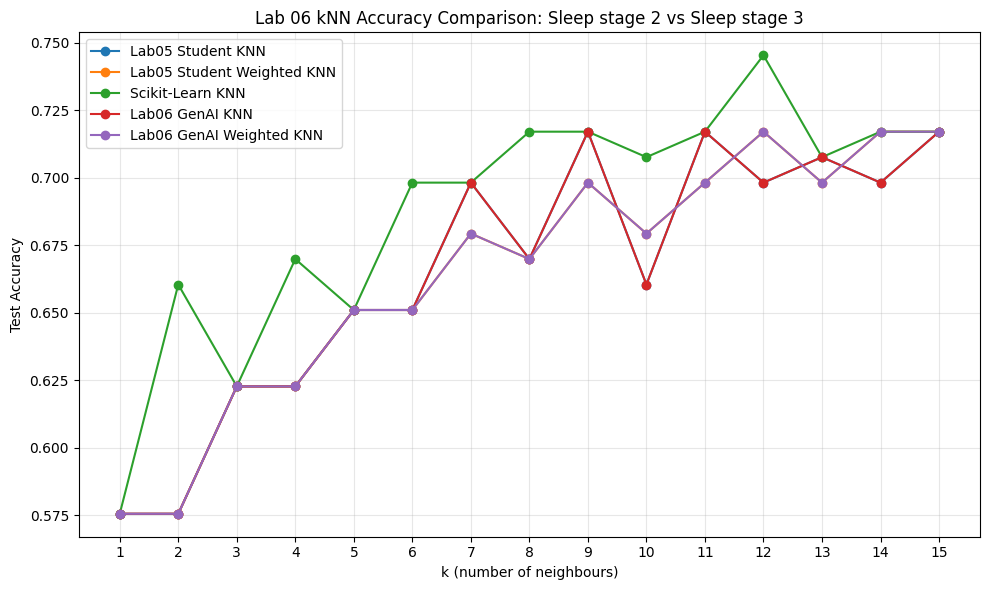

In [12]:

k_values = list(range(1, 16))

k_sweep_records = []

for k in k_values:
    # Lab 05 student-written standard kNN
    student_model = CustomKNNClassifier(
        k=k,
        distance_metric='euclidean',
        sort_algorithm='quick',
        weighted=False
    ).fit(X_train, y_train)

    student_accuracy = student_model.score(
        X_test,
        y_test
    )

    # Lab 05 student-written distance-weighted kNN
    student_weighted_model = CustomKNNClassifier(
        k=k,
        distance_metric='euclidean',
        sort_algorithm='quick',
        weighted=True
    ).fit(X_train, y_train)

    student_weighted_accuracy = student_weighted_model.score(
        X_test,
        y_test
    )

    # Scikit-learn reference
    sklearn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='uniform'
    ).fit(X_train, y_train)

    sklearn_accuracy = sklearn_model.score(
        X_test,
        y_test
    )

    # Lab 06 GenAI-assisted standard kNN
    ai_model = GenAIKNNClassifier(
        k=k,
        metric='euclidean',
        weights='uniform'
    ).fit(X_train, y_train)

    ai_accuracy = ai_model.score(
        X_test,
        y_test
    )

    # Lab 06 GenAI-assisted weighted kNN
    ai_weighted_model = GenAIKNNClassifier(
        k=k,
        metric='euclidean',
        weights='distance'
    ).fit(X_train, y_train)

    ai_weighted_accuracy = ai_weighted_model.score(
        X_test,
        y_test
    )

    k_sweep_records.append({
        'k': k,
        'Lab05 Student KNN': student_accuracy,
        'Lab05 Student Weighted KNN': student_weighted_accuracy,
        'Scikit-Learn KNN': sklearn_accuracy,
        'Lab06 GenAI KNN': ai_accuracy,
        'Lab06 GenAI Weighted KNN': ai_weighted_accuracy
    })


k_sweep_results = pd.DataFrame(k_sweep_records)

display(k_sweep_results)

plt.figure(figsize=(10, 6))

for column in k_sweep_results.columns[1:]:
    plt.plot(
        k_sweep_results['k'],
        k_sweep_results[column],
        marker='o',
        label=column
    )

plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title(
    f'Lab 06 kNN Accuracy Comparison: '
    f'{CLASS_A} vs {CLASS_B}'
)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    'lab06_knn_k_sweep.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

k_sweep_results.to_csv(
    'lab06_knn_k_sweep.csv',
    index=False
)



## 11. A3 — Three-version performance comparison

The assignment requires the following three implementations:

1. **Student-written kNN:** the Lab 05 `CustomKNNClassifier`;
2. **Scikit-learn kNN:** `KNeighborsClassifier`;
3. **GenAI-assisted kNN:** the Lab 06 `GenAIKNNClassifier`.

### Fair-comparison protocol
- same 38-dimensional project features;
- same train/test split;
- same \(k=3\);
- Euclidean distance;
- uniform voting;
- the positive class for Precision/Recall/F1 is encoded class **1 (Sleep stage 3)**;
- each model is instantiated, fitted, and used to predict the same test set **10 times**;
- mean wall-clock runtime is reported over those 10 runs.


In [13]:

# ============================================================
# A3 PERFORMANCE BENCHMARK
# GenAI tool used for benchmark structure: ChatGPT (OpenAI)
# ============================================================

def calculate_classification_metrics(y_true, y_pred):
    """
    Use the same sklearn metric functions for all three models
    so that only the kNN implementation changes.
    """
    return {
        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),
        'Precision': precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        'Recall': recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        'F1-score': f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    }


def benchmark_knn_model(
    model_factory,
    X_train,
    y_train,
    X_test,
    y_test,
    runs=10
):
    run_times = []
    final_predictions = None

    for _ in range(runs):
        model = model_factory()

        start_time = time.perf_counter()

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        elapsed_time = (
            time.perf_counter()
            - start_time
        )

        run_times.append(elapsed_time)
        final_predictions = predictions

    metrics = calculate_classification_metrics(
        y_test,
        final_predictions
    )

    return {
        **metrics,
        'Mean Time (s)': float(np.mean(run_times)),
        'Std Time (s)': float(np.std(run_times)),
        'Runs': int(runs),
        'Predictions': final_predictions,
        'Run Times': np.array(run_times)
    }


model_factories = {
    'Lab05 Student KNN': lambda: CustomKNNClassifier(
        k=K_DEFAULT,
        distance_metric='euclidean',
        sort_algorithm='quick',
        weighted=False
    ),

    'Scikit-Learn KNN': lambda: KNeighborsClassifier(
        n_neighbors=K_DEFAULT,
        metric='euclidean',
        weights='uniform'
    ),

    'Lab06 GenAI KNN': lambda: GenAIKNNClassifier(
        k=K_DEFAULT,
        metric='euclidean',
        weights='uniform'
    )
}


performance_records = []
prediction_table = pd.DataFrame({
    'Actual': y_test
})

runtime_runs = {}

for model_name, factory in model_factories.items():
    result = benchmark_knn_model(
        factory,
        X_train,
        y_train,
        X_test,
        y_test,
        runs=N_BENCHMARK_RUNS
    )

    performance_records.append({
        'Model': model_name,
        'k': K_DEFAULT,
        'Accuracy': result['Accuracy'],
        'Precision': result['Precision'],
        'Recall': result['Recall'],
        'F1-score': result['F1-score'],
        'Mean Time (s)': result['Mean Time (s)'],
        'Std Time (s)': result['Std Time (s)'],
        'Runs': result['Runs']
    })

    prediction_table[model_name] = result[
        'Predictions'
    ]

    runtime_runs[model_name] = result[
        'Run Times'
    ]


performance_comparison = pd.DataFrame(
    performance_records
)

display(performance_comparison)

print(
    "\nAll performance values above were calculated "
    f"on the same test set using {N_BENCHMARK_RUNS} timing runs."
)

performance_comparison.to_csv(
    'lab06_knn_performance_comparison.csv',
    index=False
)

prediction_table.to_csv(
    'lab06_knn_predictions.csv',
    index=False
)

runtime_table = pd.DataFrame({
    model_name: values
    for model_name, values in runtime_runs.items()
})

runtime_table.index = np.arange(
    1,
    len(runtime_table) + 1
)

runtime_table.index.name = 'run'

runtime_table.to_csv(
    'lab06_runtime_10_runs.csv'
)


,Model,k,Accuracy,Precision,Recall,F1-score,Mean Time (s),Std Time (s),Runs
0,Lab05 Student KNN,3,0.622642,0.32,0.258065,0.285714,0.353918,0.013988,10
1,Scikit-Learn KNN,3,0.622642,0.32,0.258065,0.285714,0.002067,0.000215,10
2,Lab06 GenAI KNN,3,0.622642,0.32,0.258065,0.285714,0.010336,0.000475,10



All performance values above were calculated on the same test set using 10 timing runs.



## 12. A3 visual comparison


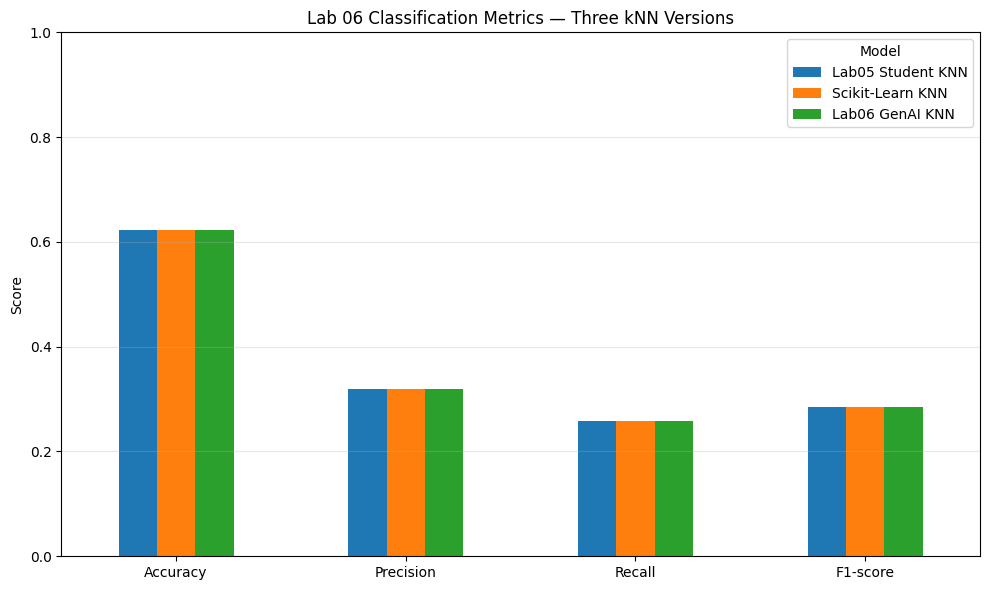

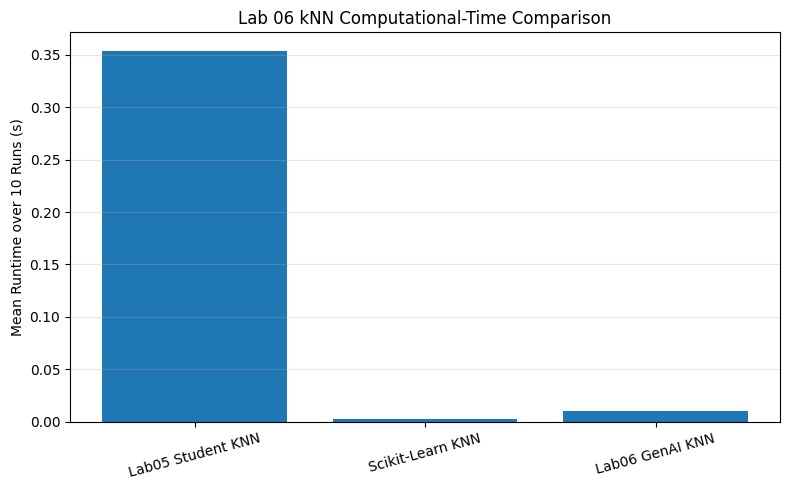

In [14]:

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
]

metric_plot_data = (
    performance_comparison
    .set_index('Model')[metric_columns]
    .T
)

ax = metric_plot_data.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title(
    'Lab 06 Classification Metrics — Three kNN Versions'
)
ax.grid(
    axis='y',
    alpha=0.3
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    'lab06_knn_metric_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(
    performance_comparison['Model'],
    performance_comparison['Mean Time (s)']
)

plt.ylabel(
    f'Mean Runtime over {N_BENCHMARK_RUNS} Runs (s)'
)
plt.title(
    'Lab 06 kNN Computational-Time Comparison'
)
plt.xticks(rotation=15)
plt.grid(
    axis='y',
    alpha=0.3
)
plt.tight_layout()
plt.savefig(
    'lab06_knn_runtime_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()



## 13. Additional functional checks after A3

These checks verify that all three implementations returned a valid prediction for every test sample and allow direct inspection of whether the implementations agree.


In [15]:

post_benchmark_tests = []

for model_name in (
    'Lab05 Student KNN',
    'Scikit-Learn KNN',
    'Lab06 GenAI KNN'
):
    predictions = prediction_table[model_name].to_numpy()

    post_benchmark_tests.append({
        'test_case': f'{model_name}: prediction count',
        'status': (
            'PASS'
            if len(predictions) == len(y_test)
            else 'FAIL'
        ),
        'detail': (
            f'predictions={len(predictions)}, '
            f'test_samples={len(y_test)}'
        )
    })

    post_benchmark_tests.append({
        'test_case': f'{model_name}: valid labels only',
        'status': (
            'PASS'
            if set(np.unique(predictions))
            .issubset(set(np.unique(y_train)))
            else 'FAIL'
        ),
        'detail': (
            f'predicted_labels='
            f'{np.unique(predictions).tolist()}'
        )
    })


student_vs_ai_agreement = np.mean(
    prediction_table['Lab05 Student KNN'].to_numpy()
    ==
    prediction_table['Lab06 GenAI KNN'].to_numpy()
)

student_vs_sklearn_agreement = np.mean(
    prediction_table['Lab05 Student KNN'].to_numpy()
    ==
    prediction_table['Scikit-Learn KNN'].to_numpy()
)

post_benchmark_tests.extend([
    {
        'test_case': 'Student vs GenAI prediction agreement',
        'status': 'PASS',
        'detail': f'agreement={student_vs_ai_agreement:.6f}'
    },
    {
        'test_case': 'Student vs sklearn prediction agreement',
        'status': 'PASS',
        'detail': f'agreement={student_vs_sklearn_agreement:.6f}'
    }
])

post_benchmark_results = pd.DataFrame(
    post_benchmark_tests
)

display(post_benchmark_results)

all_functional_results = pd.concat(
    [
        functional_test_results,
        post_benchmark_results
    ],
    ignore_index=True
)

all_functional_results.to_csv(
    'lab06_functional_test_results.csv',
    index=False
)

print(
    "\nOverall functional-test summary:",
    all_functional_results['status']
    .value_counts()
    .to_dict()
)


,test_case,status,detail
0,Lab05 Student KNN: prediction count,PASS,"predictions=106, test_samples=106"
1,Lab05 Student KNN: valid labels only,PASS,"predicted_labels=[0, 1]"
2,Scikit-Learn KNN: prediction count,PASS,"predictions=106, test_samples=106"
3,Scikit-Learn KNN: valid labels only,PASS,"predicted_labels=[0, 1]"
4,Lab06 GenAI KNN: prediction count,PASS,"predictions=106, test_samples=106"
5,Lab06 GenAI KNN: valid labels only,PASS,"predicted_labels=[0, 1]"
6,Student vs GenAI prediction agreement,PASS,agreement=1.000000
7,Student vs sklearn prediction agreement,PASS,agreement=1.000000



Overall functional-test summary: {'PASS': 20}



## 14. Prompt log / GenAI-use record

The Lab 06 assignment requires a **GenAI chat/prompt log** to be submitted separately as a PDF.

### GenAI tool used
**ChatGPT (OpenAI)**

### Primary prompt used for this Lab 06 notebook
> “now givemme ipynb file for lab6, before that read lab 6 carefully, i have to compare with lab5 and add unit testss etc as mentioned in pdf”

The Lab 06 assignment PDF and the previous Lab 05 notebook were supplied as context to ChatGPT. The generated notebook was designed from those materials.

### Code portions assisted by ChatGPT
- alternative label encoding and missing-value imputation;
- alternative vectorized distance and neighbour-ranking functions;
- `GenAIKNNClassifier`;
- unit tests for Lab 05 and Lab 06 modular functions;
- real-data functional-test framework;
- three-version classification-metric comparison;
- 10-run timing benchmark;
- CSV export and plots.

> **Important for submission:** use the actual ChatGPT conversation/export for the required prompt-log PDF. This markdown cell is a traceability summary inside the notebook, not a substitute for an audit copy of the real conversation.



## 15. Report-ready result files

After the notebook has been executed successfully, the following files are generated:

- `lab06_unit_test_results.csv`
- `lab06_functional_test_results.csv`
- `lab06_knn_performance_comparison.csv`
- `lab06_runtime_10_runs.csv`
- `lab06_knn_predictions.csv`
- `lab06_knn_k_sweep.csv`
- `lab06_knn_k_sweep.png`
- `lab06_knn_metric_comparison.png`
- `lab06_knn_runtime_comparison.png`

The performance table is the main table required for A3.  
The unit and functional test CSV files provide the test-case names and outcomes needed for the report.


In [16]:

# Create a single ZIP containing all Lab 06 result files.
import zipfile

result_files = [
    'lab06_unit_test_results.csv',
    'lab06_functional_test_results.csv',
    'lab06_knn_performance_comparison.csv',
    'lab06_runtime_10_runs.csv',
    'lab06_knn_predictions.csv',
    'lab06_knn_k_sweep.csv',
    'lab06_knn_k_sweep.png',
    'lab06_knn_metric_comparison.png',
    'lab06_knn_runtime_comparison.png'
]

existing_result_files = [
    path
    for path in result_files
    if os.path.exists(path)
]

zip_name = 'Lab06_Sleep_EDF_results.zip'

with zipfile.ZipFile(
    zip_name,
    'w',
    zipfile.ZIP_DEFLATED
) as zip_file:
    for path in existing_result_files:
        zip_file.write(
            path,
            arcname=os.path.basename(path)
        )

print(
    f"Created {zip_name} with "
    f"{len(existing_result_files)} files."
)

try:
    from google.colab import files
    files.download(zip_name)
except ImportError:
    print(
        "Download manually from:",
        os.path.abspath(zip_name)
    )


Created Lab06_Sleep_EDF_results.zip with 9 files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## 16. Interpretation guide for the Lab 06 report

When the notebook finishes, write the report from the **executed values** rather than assuming one implementation is better.

Use the generated tables to discuss:

1. whether the three classifiers produce the same or different Accuracy, Precision, Recall, and F1-score;
2. whether the GenAI implementation preserves the functional behavior of the Lab 05 student implementation;
3. which implementation has the lowest **mean runtime over 10 runs**;
4. whether the unit and functional tests all passed;
5. why runtime can differ even when classification metrics are identical (Python loops and custom sorting versus vectorized NumPy operations versus optimized scikit-learn code);
6. the effect of class imbalance when interpreting Accuracy alone.

Do not claim a performance advantage until it is supported by the executed benchmark table.
